# Disease Outbreak Early Warning System

## Notebook 04: Time Series Forecasting Models

### Purpose

This notebook develops statistical forecasting models to predict future dengue incidence using historical surveillance data.

### Objectives

* Create forecasting-ready time series data
* Split historical data into training and testing sets
* Build Exponential Smoothing forecasts
* Build ARIMA forecasts
* Compare model performance
* Generate future outbreak forecasts

### Expected Outcome

A set of forecasting models capable of predicting future dengue incidence and supporting early warning decision systems.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

os.makedirs("images", exist_ok=True)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Loading and Preparing the Dataset

The dengue surveillance dataset is reconstructed and aggregated into a weekly time series suitable for forecasting.


In [ ]:
features = pd.read_csv(
    "/content/dengue_features_train.csv"
)

labels = pd.read_csv(
    "/content/dengue_labels_train.csv"
)

dengue_df = pd.merge(
    features,
    labels,
    on=[
        "city",
        "year",
        "weekofyear"
    ]
)

dengue_df["week_start_date"] = pd.to_datetime(
    dengue_df["week_start_date"]
)

time_series = (
    dengue_df
    .groupby("week_start_date")
    ["total_cases"]
    .sum()
)

time_series.head()

,total_cases
week_start_date,
1990-04-30,4
1990-05-07,5
1990-05-14,4
1990-05-21,3
1990-05-28,6


## Training and Testing Split

The final 20% of observations are reserved for evaluating forecasting performance.


In [ ]:
train_size = int(
    len(time_series) * 0.80
)

train = time_series[:train_size]
test = time_series[train_size:]

print("Training Observations:", len(train))
print("Testing Observations:", len(test))

Training Observations: 839
Testing Observations: 210


## Exponential Smoothing Forecast

Exponential Smoothing provides a baseline forecasting model by assigning greater weight to more recent observations.


In [ ]:
exp_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal=None
)

exp_fit = exp_model.fit()

exp_forecast = exp_fit.forecast(
    len(test)
)

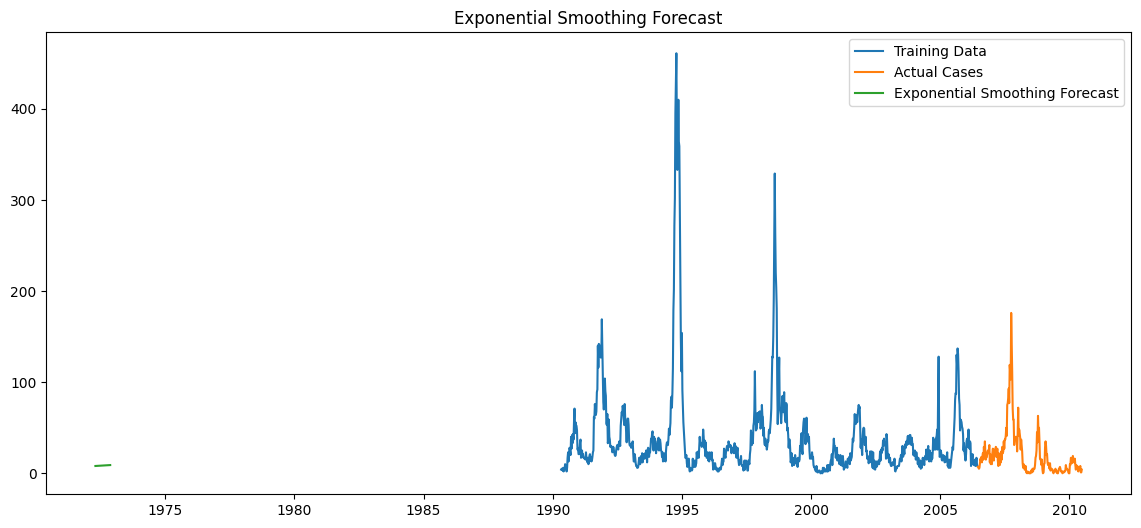

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    train,
    label="Training Data"
)

plt.plot(
    test,
    label="Actual Cases"
)

plt.plot(
    exp_forecast,
    label="Exponential Smoothing Forecast"
)

plt.legend()

plt.title(
    "Exponential Smoothing Forecast"
)

plt.savefig(
    "images/exponential_smoothing_forecast.png",
    bbox_inches="tight"
)

plt.show()

## ARIMA Forecast

The ARIMA model captures temporal dependencies and autocorrelation structures within the dengue incidence series.


In [ ]:
arima_model = ARIMA(
    train,
    order=(1,0,1)
)

arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(
    steps=len(test)
)

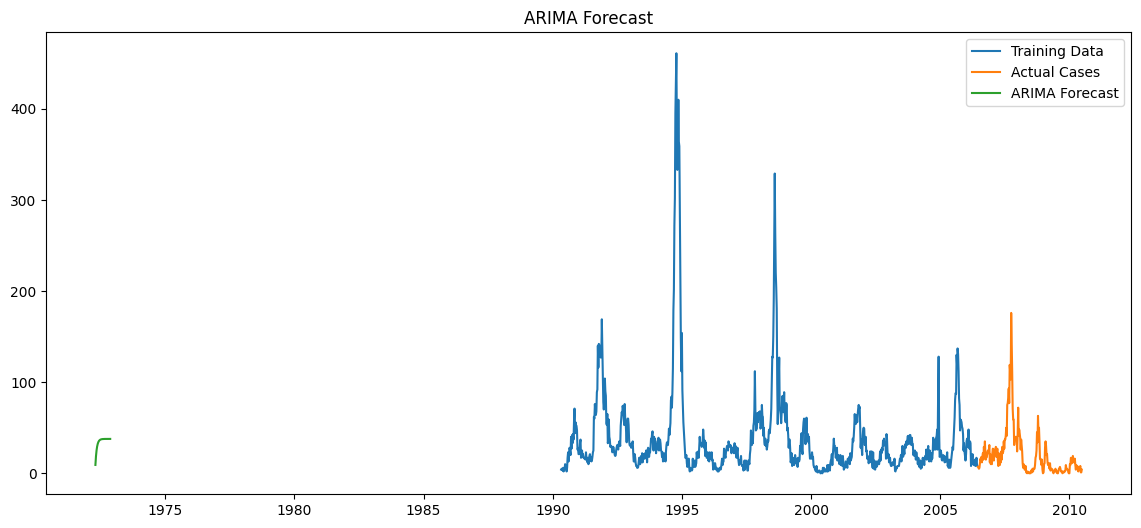

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    train,
    label="Training Data"
)

plt.plot(
    test,
    label="Actual Cases"
)

plt.plot(
    arima_forecast,
    label="ARIMA Forecast"
)

plt.legend()

plt.title(
    "ARIMA Forecast"
)

plt.savefig(
    "images/arima_forecast.png",
    bbox_inches="tight"
)

plt.show()

## Forecast Comparison

Visual comparison provides an initial assessment of model performance and forecast behavior.


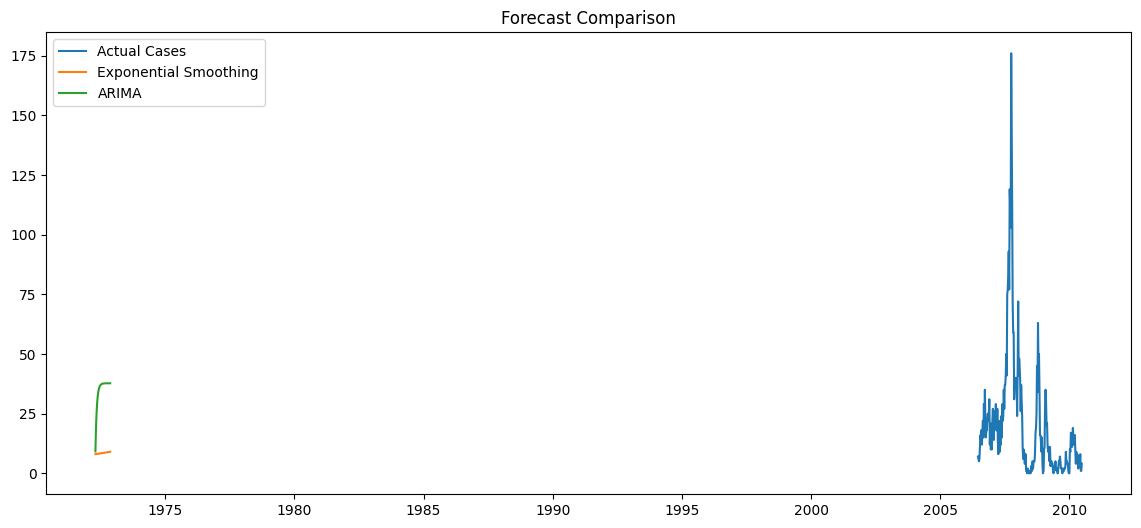

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    test,
    label="Actual Cases"
)

plt.plot(
    exp_forecast,
    label="Exponential Smoothing"
)

plt.plot(
    arima_forecast,
    label="ARIMA"
)

plt.legend()

plt.title(
    "Forecast Comparison"
)

plt.savefig(
    "images/forecast_comparison.png",
    bbox_inches="tight"
)

plt.show()

## Future Disease Forecast

The ARIMA model is used to generate future dengue incidence forecasts beyond the observed surveillance period.


In [ ]:
future_forecast = arima_fit.forecast(
    steps=12
)

future_forecast

,predicted_mean
839,9.159957
840,10.575111
841,11.920147
842,13.198538
843,14.413587
844,15.568433
845,16.666057
846,17.709297
847,18.700845
848,19.643264


## Interpretation of Forecast Results

The ARIMA model forecasts a gradual increase in weekly dengue incidence over the next twelve weeks.

Predicted cases rise from approximately 9 cases in the first forecast week to over 21 cases by the twelfth week.

This upward trend suggests increasing disease activity and highlights the importance of continuous surveillance. Such forecasts can support proactive public health interventions by providing advance warning of potential outbreak escalation.

The forecasting results will be incorporated into an outbreak detection framework in the next stage of the project.

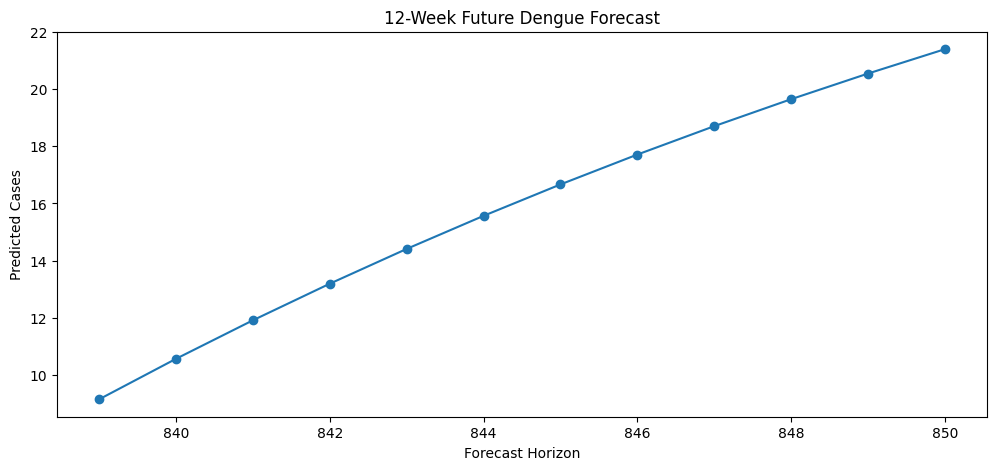

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    future_forecast,
    marker="o"
)

plt.title(
    "12-Week Future Dengue Forecast"
)

plt.xlabel("Forecast Horizon")
plt.ylabel("Predicted Cases")

plt.savefig(
    "images/future_dengue_forecast.png",
    bbox_inches="tight"
)

plt.show()

## Findings

Both Exponential Smoothing and ARIMA models successfully generated forecasts of future dengue incidence.

The ARIMA model projected a gradual increase in weekly dengue cases over the next twelve weeks, with predicted incidence increasing from approximately 9 cases to over 21 cases.

This upward trajectory suggests increasing disease activity and highlights the potential value of forecasting models for proactive outbreak preparedness.

The forecasting outputs serve as the foundation for the outbreak detection and early warning framework developed in the next notebook.

In [ ]:
import os

print(os.listdir("images"))

['future_dengue_forecast.png', 'arima_forecast.png', 'forecast_comparison.png', 'exponential_smoothing_forecast.png']
